In [7]:
import glob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn.cluster as cluster
import umap
from Bio.PDB import PDBParser
from Bio.PDB.Polypeptide import PPBuilder
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

In [3]:
def get_whole_seq(binder_idx):
    # Load the PDB file
    parser = PDBParser(QUIET=True)
    ppb= PPBuilder()
    pattern = f"../../data/sequences/{str(binder_idx)}_BAX_1F16_*.pdb"
    file = glob.glob(pattern)
    structure = parser.get_structure("protein", file[0])
    chains = ppb.build_peptides(structure)
    seq_prot = chains[0].get_sequence()
    seq_pept = chains[1].get_sequence()
    return seq_prot,seq_pept

In [ ]:
df = pd.read_csv('../../data/mmpbsa/md_data_all_binders_.csv',index_col=0)
df.set_index('Binder_ID',inplace=True)
features  = ['energies','rmsd','bsa','hbond','sbridge']
n_clusters = 4
df['seq_prot'] =str
df['seq_pept'] =str
for idx in df.index:
    seq_prot, seq_pept = get_whole_seq(idx)
    df.loc[idx,'seq_prot'] = str(seq_prot)
    df.loc[idx,'seq_pept'] = str(seq_pept)

In [5]:
df

,sbridge,hbond,energies,bsa,rmsd,seq_prot,seq_pept
Binder_ID,,,,,,,
1,1.000000,2.977640,-60.670444,-1.599634,0.319568,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,TLGERILAEVNK
2,1.000000,4.460748,-64.455556,0.021146,0.237327,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,SLGDTILEEVMK
3,1.000000,3.370119,-62.511111,-1.215878,0.231807,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,SLGDTILNEVMK
4,1.307685,3.951310,-61.568222,-1.774780,0.280639,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,TLGERILEEVNK
5,1.000000,5.132062,-65.880444,-0.976195,0.282120,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,SLGQEILKEVEK
...,...,...,...,...,...,...,...
98,1.000000,2.459585,-54.654444,-1.250439,0.342190,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,SVRELTELMA
99,1.000000,2.238103,-58.685556,-0.979634,0.320138,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,TVREMTEIMM
100,1.393881,3.403594,-59.273333,-0.932390,0.250268,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,SVRELTRLMA


In [94]:
# df = pd.read_csv('../../data/mmpbsa/md_data_all_binders_raw.csv',index_col=0)
# df.set_index('Binder_ID',inplace=True)
# features  = ['energies','rmsd','bsa','hbond','sbridge']
# n_clusters = 3
# scaler = preprocessing.Normalizer()
# df_array = scaler.fit_transform(df[features])
# df = pd.DataFrame(df_array,columns=features)

/tmp/ipykernel_108756/544177760.py:11: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


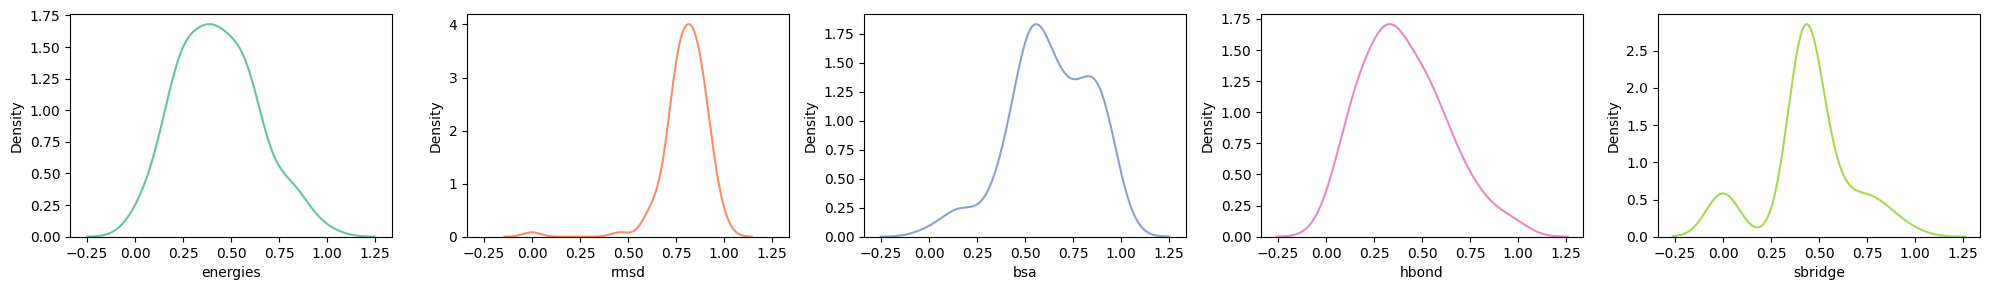

In [5]:

n_features = len(features)
feature_colors = sns.color_palette("Set2", n_features)

fig, axes = plt.subplots(1, n_features, figsize=(4 * n_features, 3 * 1), constrained_layout=True,sharex=True)

for i, idx_feat in enumerate(features):
        ax = axes[i]
        sns.kdeplot(df[idx_feat], ax=ax, color=feature_colors[i])
        

plt.tight_layout()
plt.show()

### own domain knowledge weighting

In [6]:
df['final_score'] = df['energies'] * 1.5 + df['rmsd'] * 1 + df['bsa'] * 1.1 + df['hbond'] * 1.3 + df['sbridge'] * 1.2

In [9]:
df[['final_score','seq_prot','seq_pept']].to_csv('../../data/mmpbsa/finished_data.csv')

In [6]:
df_cosine_sim = pd.read_csv('../../data/mmpbsa/finished_data.csv')

In [9]:
df_cosine_sim

,Binder_ID,final_score,seq_prot,seq_pept
0,1,2.610130,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,TLGERILAEVNK
1,2,2.568941,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,SLGDTILEEVMK
2,3,2.790536,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,SLGDTILNEVMK
3,4,3.185673,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,TLGERILEEVNK
4,5,3.139916,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,SLGQEILKEVEK
...,...,...,...,...
97,98,2.020302,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,SVRELTELMA
98,99,2.074002,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,TVREMTEIMM
99,100,2.686992,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,SVRELTRLMA
100,101,3.581628,QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQ...,SDMERWRELADWL


In [12]:
scaler = MinMaxScaler(feature_range=(-1,1))
df_cosine_sim['final_score'] = scaler.fit_transform(df_cosine_sim[['final_score']])

In [14]:
df_cosine_sim[['final_score','seq_prot','seq_pept']].to_csv('../../data/mmpbsa/finished_data_cosine_sim.csv')

### classification idea

/home/jkunz/master_uni_hd/internship_amsterdam/work/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


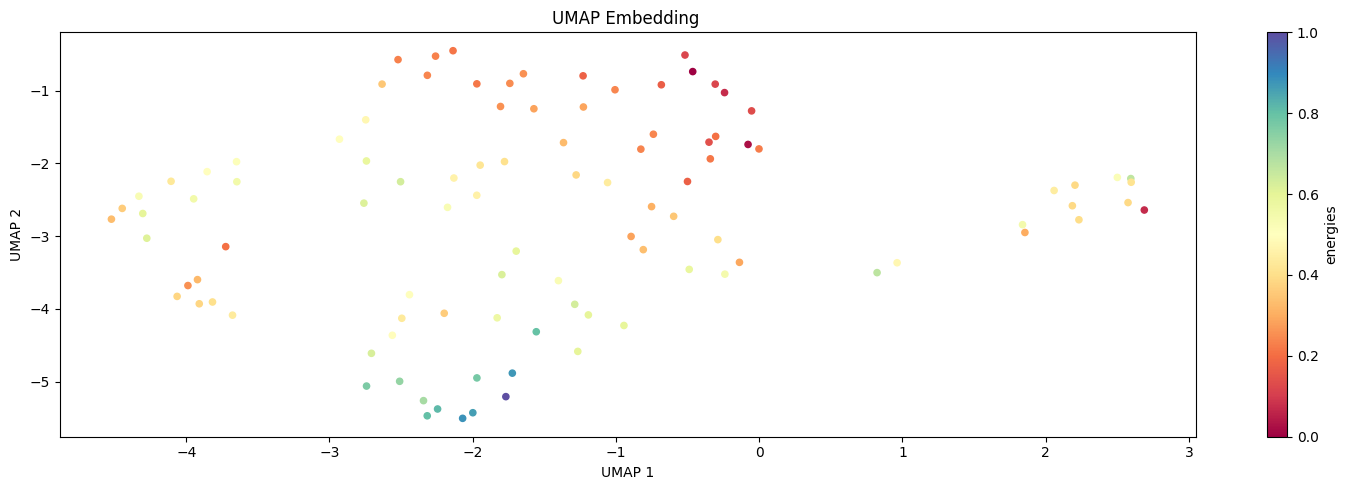

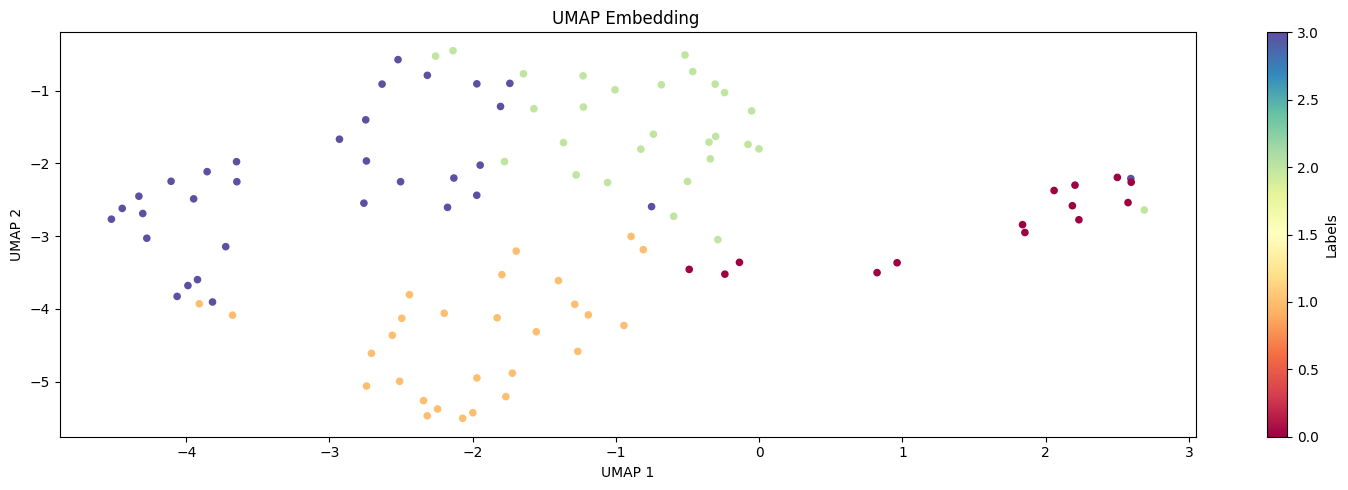

In [96]:
kmeans_labels = cluster.KMeans(n_clusters=n_clusters,random_state=1).fit_predict(np.array(df[features ]))
embedding = umap.UMAP(random_state=1).fit_transform(np.array(df[features ]))

plt.figure(figsize=(15, 5))
scatter = plt.scatter(embedding[:, 0], embedding[:, 1], s=20, c=df['energies'].astype(float), cmap='Spectral')
plt.colorbar(scatter, label='energies')

plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Embedding ')
plt.tight_layout()
plt.figure(figsize=(15, 5))
scatter = plt.scatter(embedding[:, 0], embedding[:, 1], s=20, c=kmeans_labels.astype(float), cmap='Spectral')
plt.colorbar(scatter, label='Labels')

plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Embedding ')
plt.tight_layout()

In [97]:
df['labels'] = kmeans_labels
# Calculate mean energies for each label
mean_energies = [df[df['labels'] == i]['energies'].mean() for i in range(5)]

# Create a mapping from old labels to new labels (sorted by mean energy)
label_mapping = {old_label: new_label for new_label, old_label in enumerate(sorted(range(5), key=lambda i: mean_energies[i]))}

# Apply the mapping to relabel
df['labels'] = df['labels'].map(label_mapping)
kmeans_labels = df['labels'].values

print('binder classes mean:')
print(f"no binder: {df[df['labels']== 0]['energies'].mean()}")
print(f"less worse binder:{df[df['labels']== 1]['energies'].mean()}")
print(f"mid binder:{df[df['labels']== 2]['energies'].mean()}")
print(f"semi good binder:{df[df['labels']== 3]['energies'].mean()}")
print(f"best binder:{df[df['labels']== 4]['energies'].mean()}")

binder classes mean:
no binder: 0.21909526935687232
less worse binder:0.4288750157492325
mid binder:0.45391845639523026
semi good binder:0.6278709784986268
best binder:nan


/tmp/ipykernel_86862/3479206493.py:22: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


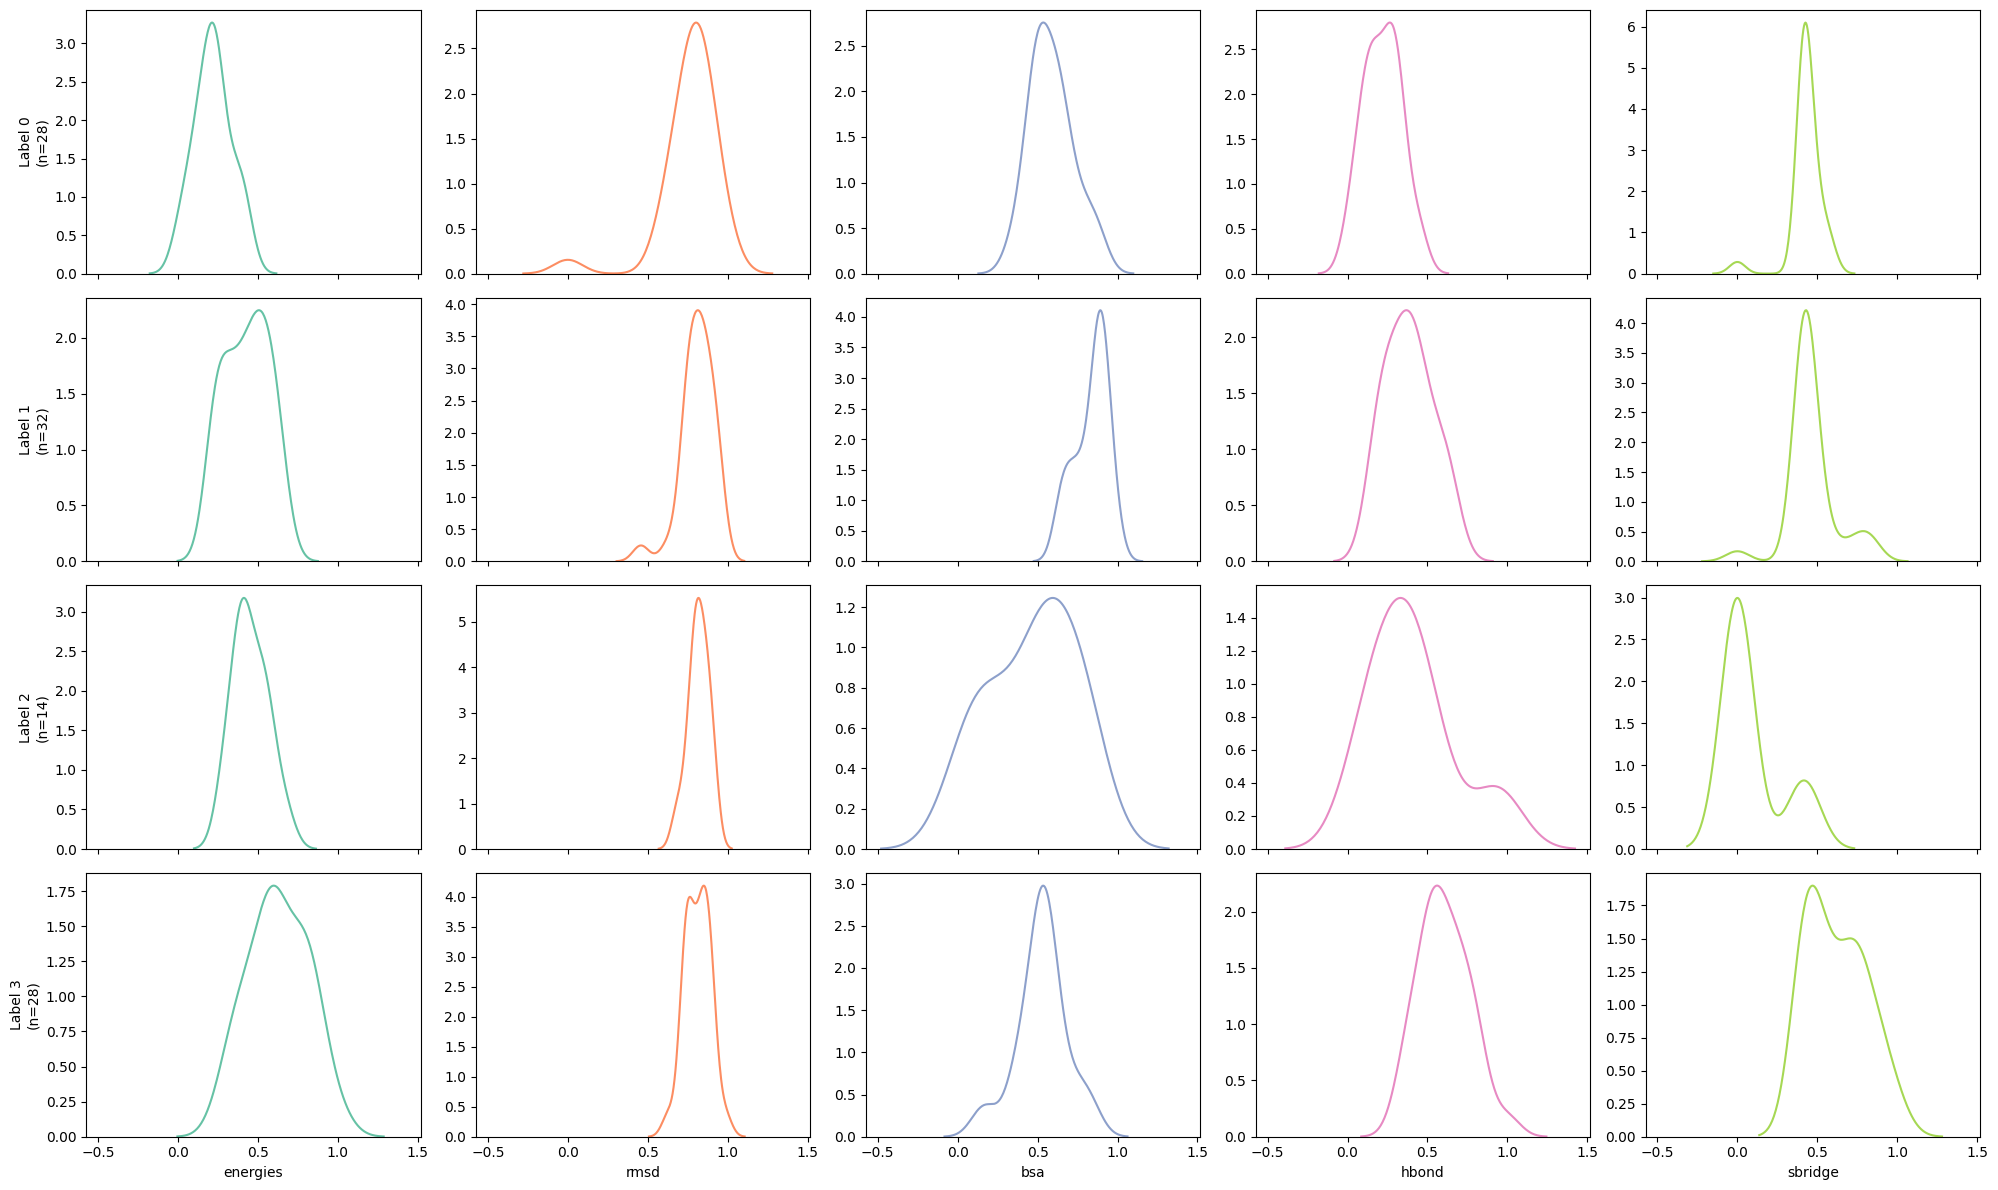

In [98]:

labels = sorted(df['labels'].unique())
n_labels = len(labels)
n_features = len(features)
feature_colors = sns.color_palette("Set2", n_features)

fig, axes = plt.subplots(n_labels, n_features, figsize=(4 * n_features, 3 * n_labels), constrained_layout=True,sharex=True)

for i, lab in enumerate(labels):
    subset = df[df['labels'] == lab]
    for j, feat in enumerate(features):
        ax = axes[i, j]
        sns.kdeplot(subset[feat], ax=ax, color=feature_colors[j])
        if j == 0:
            ax.set_ylabel(f"Label {lab}\n(n={len(subset)})")
        else:
            ax.set_ylabel('')
        if i == n_labels - 1:
            ax.set_xlabel(feat)
        else:
            ax.set_xlabel('')

plt.tight_layout()
plt.show()

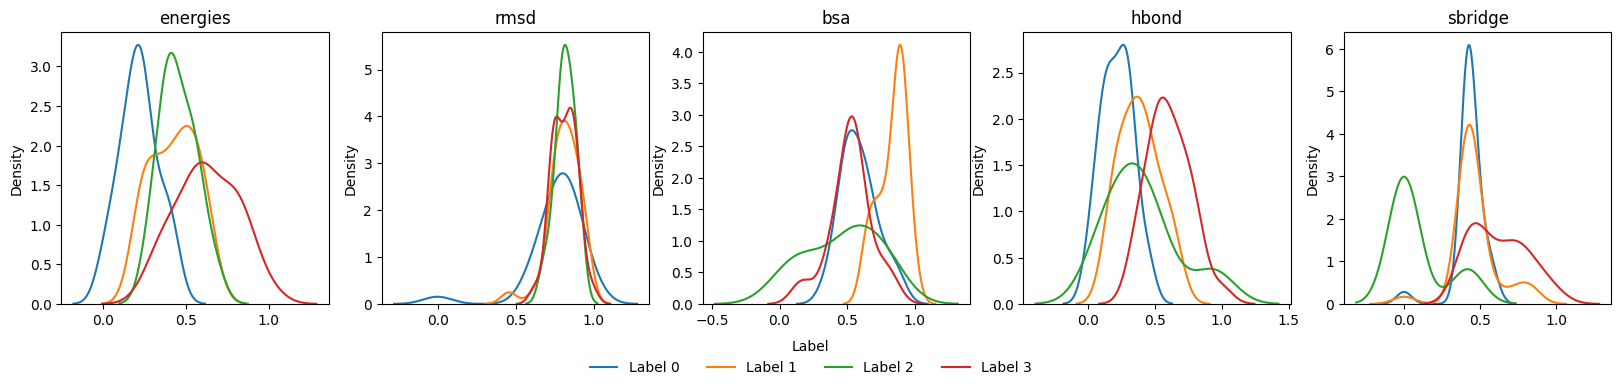

In [99]:

labels = sorted(df['labels'].unique())
n_features = len(features)

fig, axes = plt.subplots(1, n_features, figsize=(4 * n_features, 4), constrained_layout=False)

for j, feat in enumerate(features):
    ax = axes[j]
    for lab in labels:
        subset = df[df['labels'] == lab]
        sns.kdeplot(subset[feat], ax=ax, label=f"Label {lab}")
    ax.set_title(feat)
    ax.set_xlabel('')
    ax.set_ylabel('Density')

# Place a wide legend below the figure
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.subplots_adjust(bottom=0.2)
fig.legend(handles, legend_labels, loc='lower center', ncol=len(labels), title='Label', frameon=False)

plt.show()


In [101]:
from sklearn.linear_model import LinearRegression

# Prepare features (X) and target (y)
X = df[features]
Y= df['labels']

# Create and fit the linear regression model
model = LinearRegression()
model.fit(X,Y)

print(f'features: {features}')
print("Linear Regression Model:")
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")
print(f"R² Score: {model.score(X, Y)}")

features: ['energies', 'rmsd', 'bsa', 'hbond', 'sbridge']
Linear Regression Model:
Coefficients: [ 2.65977285 -0.20243327 -1.20187952  1.85964822  0.26731154]
Intercept: 0.3226762421776683
R² Score: 0.6325664226473459


In [106]:
model.intercept_ + (X * model.coef_).sum(axis=1)

Binder_ID
1      0.386929
2      1.930027
3      0.812900
4      0.713190
5      1.799361
         ...   
98    -0.083003
99     0.286123
100    0.755970
101    1.843378
102    2.573408
Length: 102, dtype: float64

In [109]:
df['final_score'] = model.intercept_ + (X * model.coef_).sum(axis=1)
df.index = df.index.astype(str)

In [115]:
df

,sbridge,hbond,energies,bsa,rmsd,labels,final_score
Binder_ID,,,,,,,
1,0.416667,0.276273,0.179521,0.754123,0.652157,0,0.386929
2,0.416667,0.539758,0.292472,0.099804,0.818764,2,1.930027
3,0.416667,0.346000,0.234448,0.599198,0.829946,0,0.812900
4,0.544869,0.449253,0.206312,0.824831,0.731021,1,0.713190
5,0.416667,0.659022,0.334991,0.502437,0.728020,3,1.799361
...,...,...,...,...,...,...,...
98,0.416666,0.184237,0.000000,0.613151,0.606329,0,-0.083003
99,0.416667,0.144889,0.120291,0.503825,0.651002,0,0.286123
100,0.580784,0.351947,0.137831,0.484753,0.792547,0,0.755970


### regression idea with pca

In [ ]:
# Prepare features (X) and target (y)
X = df[['energies','rmsd','bsa','hbond','sbridge']]
Y= df['labels']

# Hold out a certain percentile of each label for testing
test_percentile = 20  # Hold out 20% for testing

X_train, X_test = [], []
Y_train, Y_test = [], []

for label in df['labels'].unique():
    label_mask = df['labels'] == label
    label_indices = df[label_mask].index
    
    n_test = max(1, int(len(label_indices) * test_percentile / 100))
    test_indices = np.random.choice(label_indices, size=n_test, replace=False)
    train_indices = label_indices.difference(test_indices)
    
    X_train.append(X.loc[train_indices])
    X_test.append(X.loc[test_indices])
    Y_train.append(Y.loc[train_indices])
    Y_test.append(Y.loc[test_indices])

X_train = pd.concat(X_train)
X_test = pd.concat(X_test)
Y_train = pd.concat(Y_train)
Y_test = pd.concat(Y_test)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nTraining set label distribution:\n{Y_train.value_counts().sort_index()}")
print(f"\nTest set label distribution:\n{Y_test.value_counts().sort_index()}")


# Create and fit the linear regression model
model = LinearRegression()
model.fit(X_train,Y_train)
pred_Y = model.predict(X_test)



print("Linear Regression Model:")
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")
print(f"R² Score: {model.score(X_test, Y_test)}")

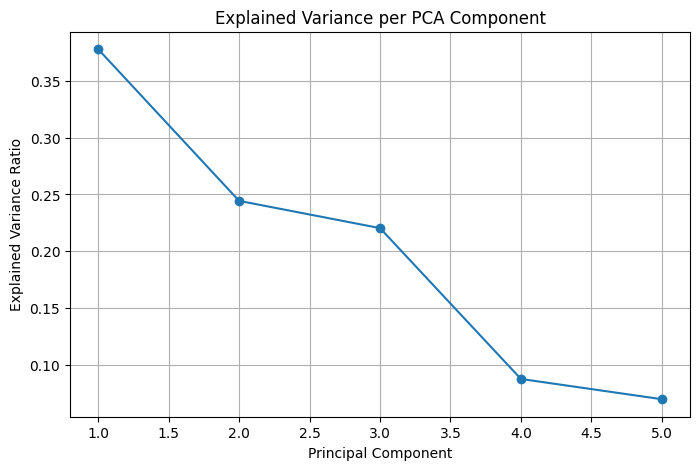

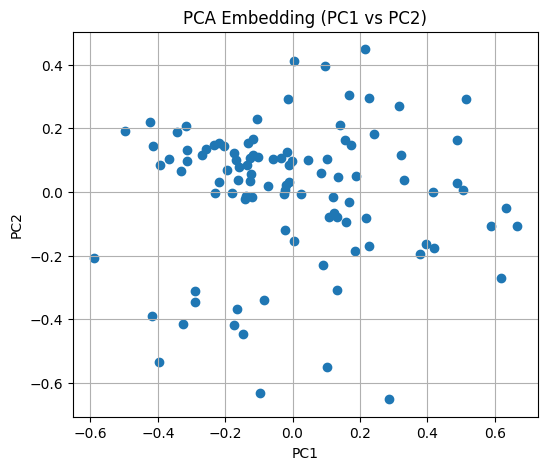


PCA Loadings:
               PC1       PC2       PC3       PC4       PC5
sbridge   0.420232  0.841125 -0.332654 -0.055060  0.047154
hbond     0.622076 -0.165138  0.224350  0.706477 -0.190547
energies  0.633886 -0.276564  0.216992 -0.688842  0.010638
bsa      -0.161001  0.429092  0.887852 -0.040804 -0.003419
rmsd      0.093246 -0.068048  0.060340  0.147277  0.980481

Top contributing feature per principal component:
PC1    energies
PC2     sbridge
PC3         bsa
PC4       hbond
PC5        rmsd
dtype: object


In [160]:
# -------------------------
# Assume df already exists
# -------------------------

# 1. Standardize the features
X = df[['sbridge', 'hbond', 'energies', 'bsa', 'rmsd']]

# 2. Run PCA
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X)

# 3. Explained variance per component
explained_variance = pca.explained_variance_ratio_
components = np.arange(1, len(explained_variance) + 1)

plt.figure(figsize=(8, 5))
plt.plot(components, explained_variance, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance per PCA Component")
plt.grid(True)
plt.show()

#4. PCA embedding (PC1 vs PC2)
plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Embedding (PC1 vs PC2)")
plt.grid(True)
plt.show()

# 5. Get PCA component loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index= df.columns[:-1]
)

print("\nPCA Loadings:")
print(loadings)

# 6. Identify the dominant features per component
top_features = loadings.abs().idxmax()
print("\nTop contributing feature per principal component:")
print(top_features)

In [178]:
pca.components[0]

AttributeError: 'PCA' object has no attribute 'components'